# FDS 보고서용 시각화 (한 파일)

`dataset/creditcard.csv` 필요. `fds_pipeline.py`와 **동일한 전처리·분할·SMOTETomek·random_state=42** 기준.

실행 후 `report_figures/` 폴더에 PNG 저장.

보고서 **그림 11~13**(모델 구조·앙상블·학습곡선 등 도식)은 이 노트북에 포함하지 않습니다. PNG는 본문 그림 번호에 맞춰 `02_`…`10_`, `14_`, `15_` 접두를 사용합니다.

**맨 아래**에는 **1차 5종 모델 비교**(`model_compare_all_*`)와 **2차 3종·검증 임계값**(`model_round2_val_thr.csv`)을 각각 스크립트로 돌리고 결과를 붙이는 섹션을 두었다. `model_compare_all_` 접두는 본문 그림 번호와 별도다.



In [2]:
# 저장 폴더
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.combine import SMOTETomek
import shap

# 한글: seaborn이 Arial로 덮어쓰기 전에 TTF 직접 등록 후, set_theme 이후에 다시 지정
def _setup_korean_font():
    candidates = [
        Path(r"C:\Windows\Fonts\malgun.ttf"),
        Path(r"C:\Windows\Fonts\malgunsl.ttf"),
    ]
    for font_path in candidates:
        if not font_path.is_file():
            continue
        try:
            font_manager.fontManager.addfont(str(font_path))
        except Exception:
            pass
        fp = font_manager.FontProperties(fname=str(font_path))
        name = fp.get_name()
        plt.rcParams["font.family"] = name
        plt.rcParams["font.sans-serif"] = [name, "Malgun Gothic", "DejaVu Sans"]
        return name
    plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "AppleGothic", "DejaVu Sans"]
    plt.rcParams["font.family"] = "sans-serif"
    return None

CSV_PATH = Path("dataset/creditcard.csv")
OUT = Path("report_figures")
OUT.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
_ko = _setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False
if _ko:
    print("한글 폰트:", _ko)
else:
    print("경고: malgun.ttf 없음 — 한글 깨질 수 있음")
print("저장 경로:", OUT.resolve())


한글 폰트: Malgun Gothic
저장 경로: D:\personalProject\report_figures


d:\personalProject\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_raw = pd.read_csv(CSV_PATH)
assert "Class" in df_raw.columns
print(df_raw.shape)
df_raw["Class"].value_counts()


(284807, 31)


Class
0    284315
1       492
Name: count, dtype: int64

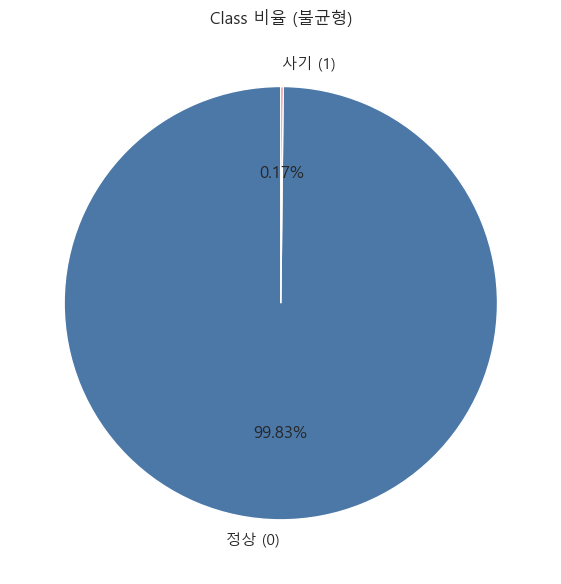

In [5]:
# 보고서 그림 2 — 클래스 비율 (파이)
fig, ax = plt.subplots(figsize=(6, 6))
counts = df_raw["Class"].value_counts()
labels = ["정상 (0)", "사기 (1)"]
colors = ["#4C78A8", "#E45756"]
ax.pie(counts.sort_index(), labels=labels, autopct="%1.2f%%", colors=colors, startangle=90)
ax.set_title("Class 비율 (불균형)")
plt.tight_layout()
fig.savefig(OUT / "02_class_pie.png", dpi=150)
plt.show()


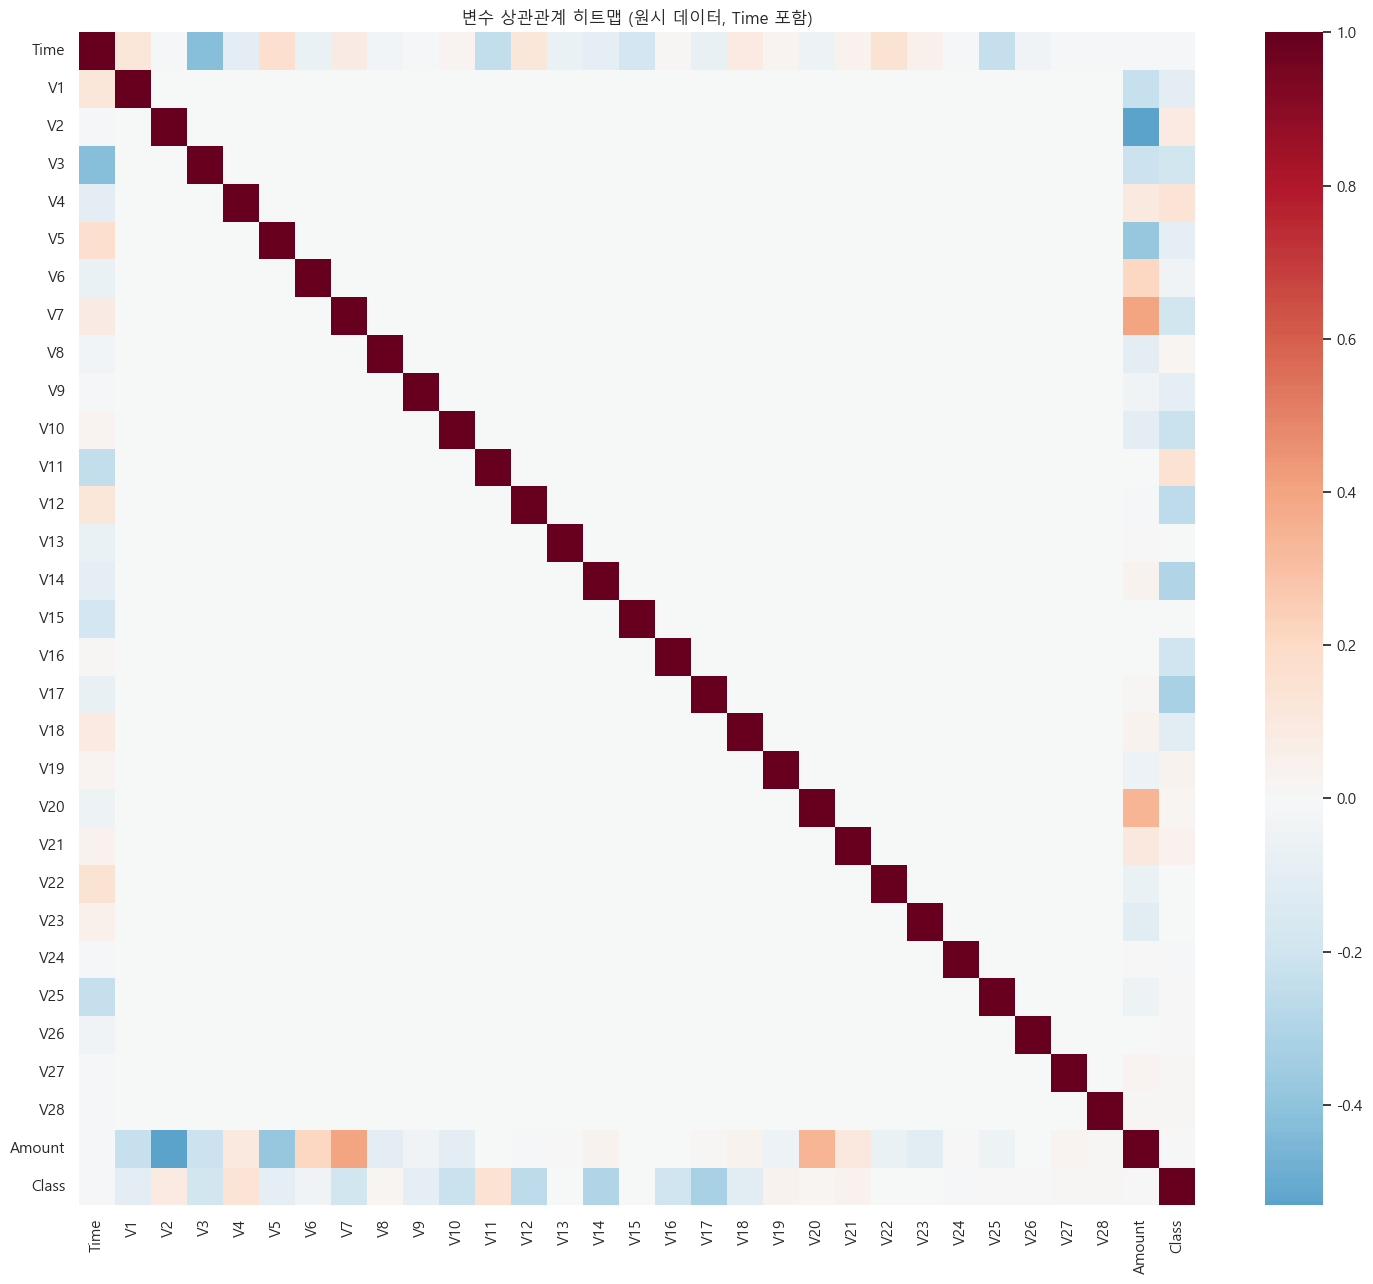

In [6]:
# 보고서 그림 3 — 상관관계 히트맵 — 원시 CSV 수치형 전부 (Time, V1~V28, Amount, Class)
# Time은 '첫 거래 이후 경과 초'라 스케일이 Amount·V와 다름. 보고서에 한 줄 설명 추천.
corr = df_raw.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(15, 13))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=False)
plt.title("변수 상관관계 히트맵 (원시 데이터, Time 포함)")
plt.tight_layout()
plt.savefig(OUT / "03_corr_heatmap.png", dpi=150)
plt.show()


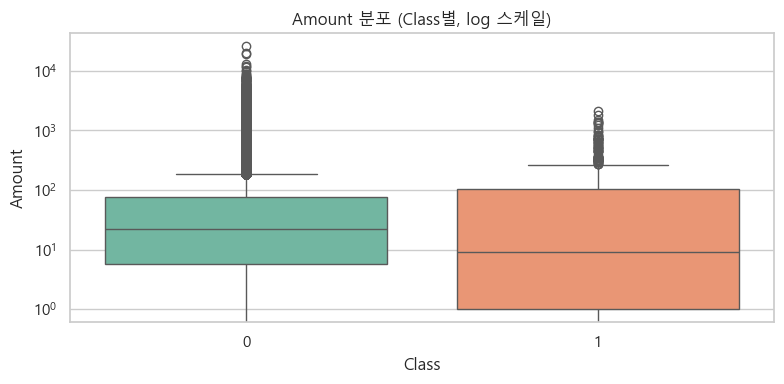

In [7]:
# 보고서 그림 4 — Amount 박스플롯 (스케일 전)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_raw, x="Class", y="Amount", hue="Class", palette="Set2", dodge=False, legend=False)
plt.yscale("log")
plt.title("Amount 분포 (Class별, log 스케일)")
plt.tight_layout()
plt.savefig(OUT / "04_amount_boxplot.png", dpi=150)
plt.show()


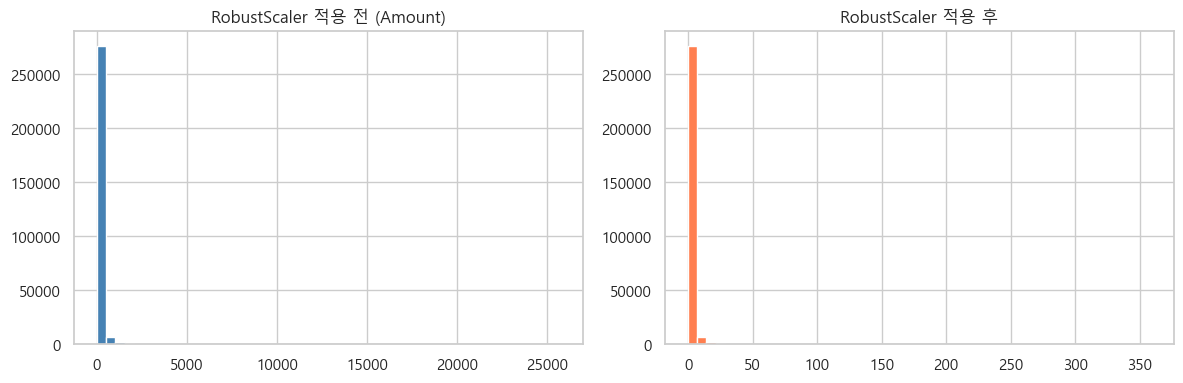

In [8]:
# 보고서 그림 5 — RobustScaler 적용 전·후 Amount 히스토그램 (전체 데이터에 fit — 파이프라인과 동일)
scaler_vis = RobustScaler()
amount_raw = df_raw["Amount"].values.reshape(-1, 1)
amount_scaled = scaler_vis.fit_transform(amount_raw).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw["Amount"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("RobustScaler 적용 전 (Amount)")
axes[1].hist(amount_scaled, bins=50, color="coral", edgecolor="white")
axes[1].set_title("RobustScaler 적용 후")
plt.tight_layout()
plt.savefig(OUT / "05_amount_hist_before_after.png", dpi=150)
plt.show()


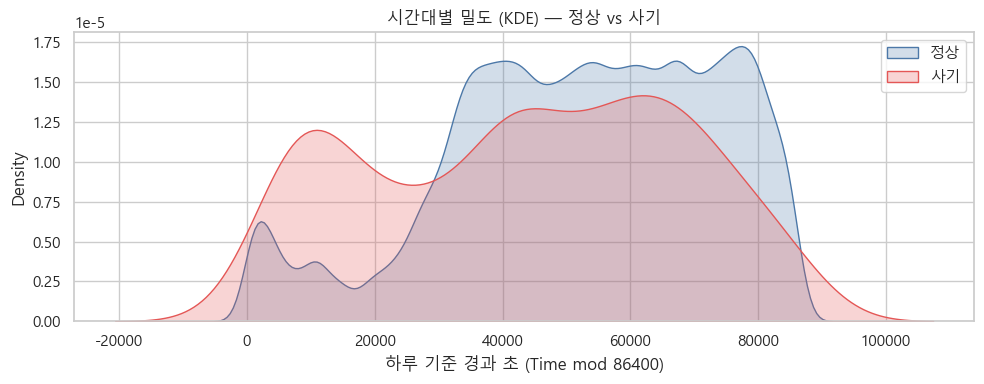

In [9]:
# 보고서 그림 6 — 시간: 누적 초 → 시각화용 '시간대(초 % 86400)' KDE (정상 vs 사기)
# 첫 거래 기준 초를 하루 주기로 접어 시간대 패턴만 보려는 목적
t = df_raw["Time"] % 86400
fig, ax = plt.subplots(figsize=(10, 4))
for label, name, color in [(0, "정상", "#4C78A8"), (1, "사기", "#E45756")]:
    sns.kdeplot(t[df_raw["Class"] == label], ax=ax, label=name, color=color, fill=True, alpha=0.25)
ax.set_xlabel("하루 기준 경과 초 (Time mod 86400)")
ax.set_title("시간대별 밀도 (KDE) — 정상 vs 사기")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "06_time_kde_by_day_seconds.png", dpi=150)
plt.show()


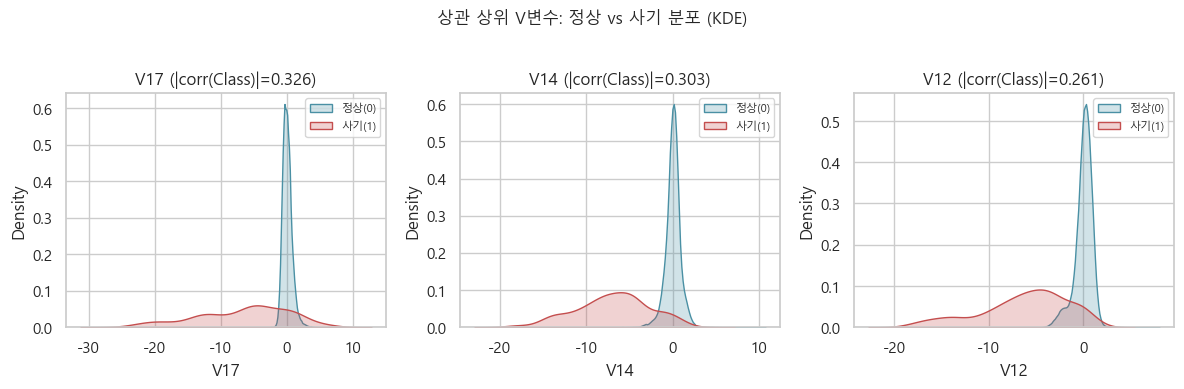

In [10]:
# 보고서 그림 7 — 상관 상위 V변수 정상 vs 사기 KDE (스크립트 `report/generate_report_extras.py`와 동일 목적; 여기서는 보고서 그림 번호 기준 `07_...` 로 저장)
# 원시 df_raw 스케일, Class와 |상관| 큰 V 상위 3개
v_cols = [c for c in df_raw.columns if c.startswith("V")]
corr_v = df_raw[v_cols + ["Class"]].corr(numeric_only=True)["Class"].drop("Class").abs()
top3 = corr_v.sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, col in zip(axes, top3):
    for label, name, color in [(0, "정상(0)", "#4a90a4"), (1, "사기(1)", "#c44e4e")]:
        subset = df_raw.loc[df_raw["Class"] == label, col]
        sns.kdeplot(subset, ax=ax, label=name, color=color, fill=True, alpha=0.25, warn_singular=False)
    ax.set_title(f"{col} (|corr(Class)|={corr_v[col]:.3f})")
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
fig.suptitle("상관 상위 V변수: 정상 vs 사기 분포 (KDE)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "07_top_v_kde_by_class.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# fds_pipeline과 동일 전처리 후 Train/Test · SMOTETomek
df = df_raw.copy()
df["Time_sin"] = np.sin(2 * np.pi * df["Time"] / 86400)
df["Time_cos"] = np.cos(2 * np.pi * df["Time"] / 86400)
df = df.drop(["Time"], axis=1)

scaler = RobustScaler()
df["Amount"] = scaler.fit_transform(df["Amount"].values.reshape(-1, 1))

X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)
print("Train 원본:", y_train.value_counts().to_dict())
print("Train SMOTETomek 후:", pd.Series(y_train_res).value_counts().to_dict())


Train 원본: {0: 227451, 1: 394}
Train SMOTETomek 후: {0: 227451, 1: 227451}


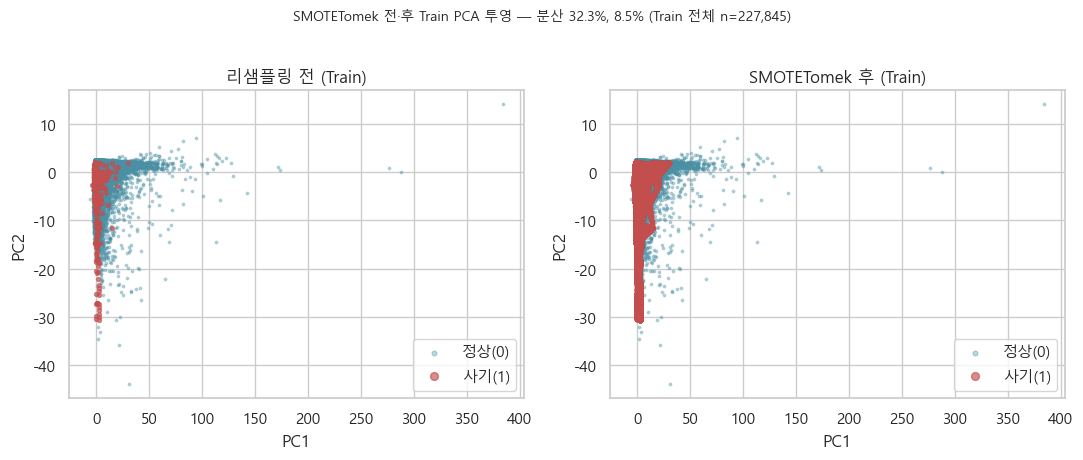

In [12]:
# 보고서 그림 8 — SMOTETomek 전·후 Train PCA 2D (스크립트와 동일 목적; 여기서는 `08_...` 로 저장)
# 아래 셀에서 만든 X_train, y_train, X_train_res, y_train_res 사용 (전체 Train·실제 리샘플 결과)
from sklearn.decomposition import PCA

_pca = PCA(n_components=2, random_state=42)
Z_before = _pca.fit_transform(X_train)
Z_after = _pca.transform(X_train_res)
_var = _pca.explained_variance_ratio_
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, Z, yy, title in [
    (axes[0], Z_before, y_train, "리샘플링 전 (Train)"),
    (axes[1], Z_after, y_train_res, "SMOTETomek 후 (Train)"),
]:
    m = yy == 0
    f = yy == 1
    ax.scatter(Z[m, 0], Z[m, 1], c="#4a90a4", s=3, alpha=0.35, label="정상(0)")
    ax.scatter(Z[f, 0], Z[f, 1], c="#c44e4e", s=8, alpha=0.65, label="사기(1)")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(markerscale=2)
fig.suptitle(
    f"SMOTETomek 전·후 Train PCA 투영 — 분산 {_var[0]:.1%}, {_var[1]:.1%} (Train 전체 n={len(y_train):,})",
    fontsize=10,
    y=1.02,
)
plt.tight_layout()
plt.savefig(OUT / "08_smotetomek_pca_before_after.png", dpi=150, bbox_inches="tight")
plt.show()


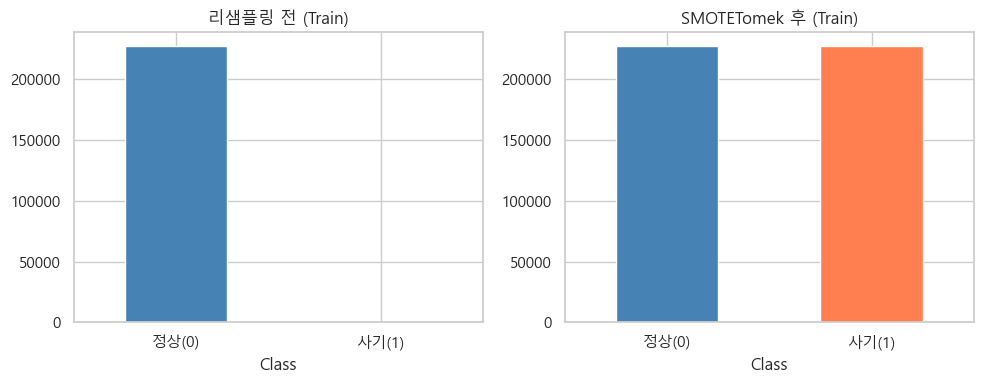

In [13]:
# 보고서 그림 9 — SMOTETomek 전·후 클래스 건수 (막대)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y_train).value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("리샘플링 전 (Train)")
pd.Series(y_train_res).value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("SMOTETomek 후 (Train)")
for ax in axes:
    ax.set_xticklabels(["정상(0)", "사기(1)"], rotation=0)
plt.tight_layout()
plt.savefig(OUT / "09_smote_class_bar_before_after.png", dpi=150)
plt.show()


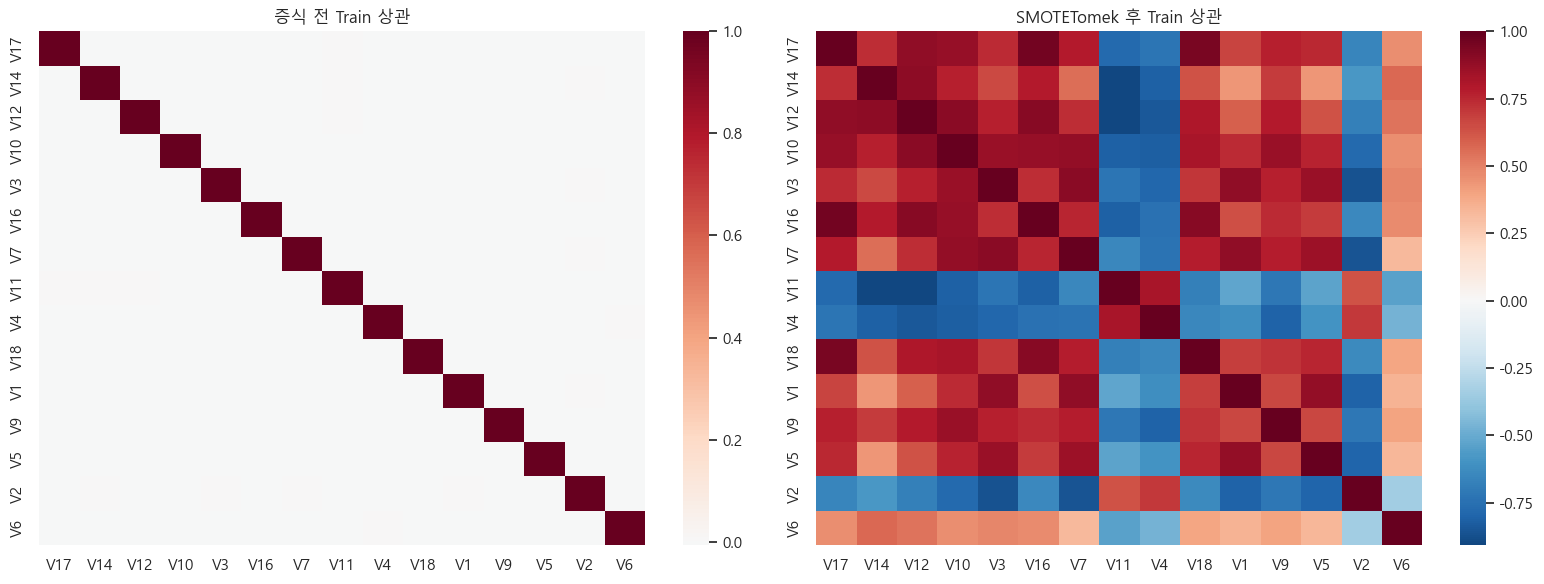

In [14]:
# 보고서 그림 10 — 리샘플링 전·후 상관 히트맵 (특성 부분만, 가독성)
feat_cols = [c for c in X_train.columns if c != "Class"]
# 열이 많으면 Class와 상관이 큰 상위 15개 + Amount 등만
if len(feat_cols) > 16:
    c_with = X_train.assign(Class=y_train).corr()["Class"].abs().sort_values(ascending=False)
    top = [c for c in c_with.index if c != "Class"][:15]
    A = X_train[top].corr()
    B = X_train_res[top].corr()
else:
    A = X_train.corr()
    B = X_train_res.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(A, ax=axes[0], cmap="RdBu_r", center=0)
axes[0].set_title("증식 전 Train 상관")
sns.heatmap(B, ax=axes[1], cmap="RdBu_r", center=0)
axes[1].set_title("SMOTETomek 후 Train 상관")
plt.tight_layout()
plt.savefig(OUT / "10_correlation_heatmap_comparison.png", dpi=150)
plt.show()


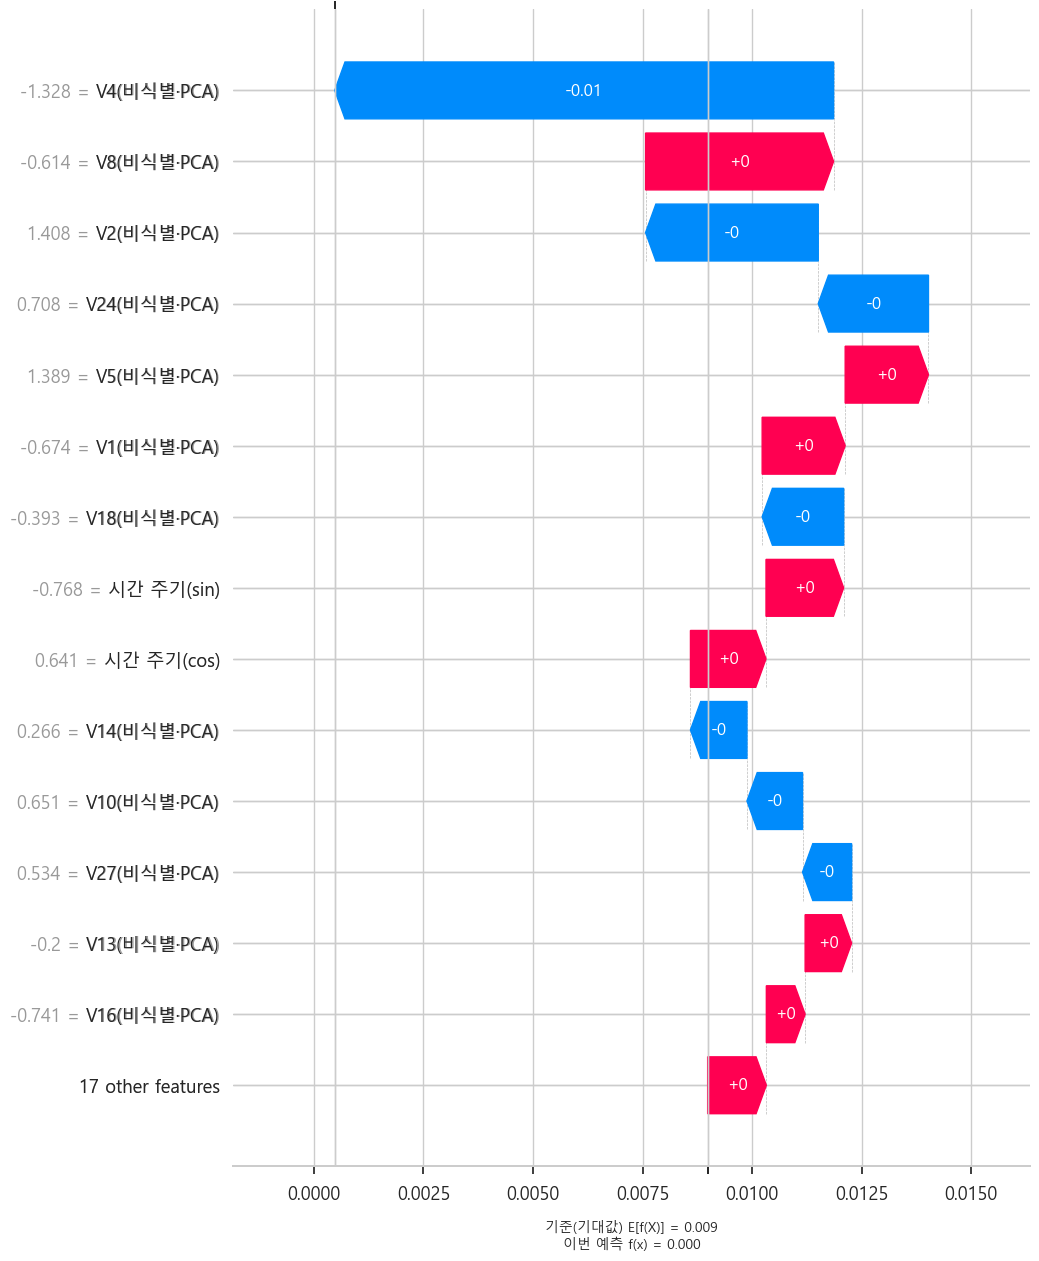

<Figure size 640x480 with 0 Axes>

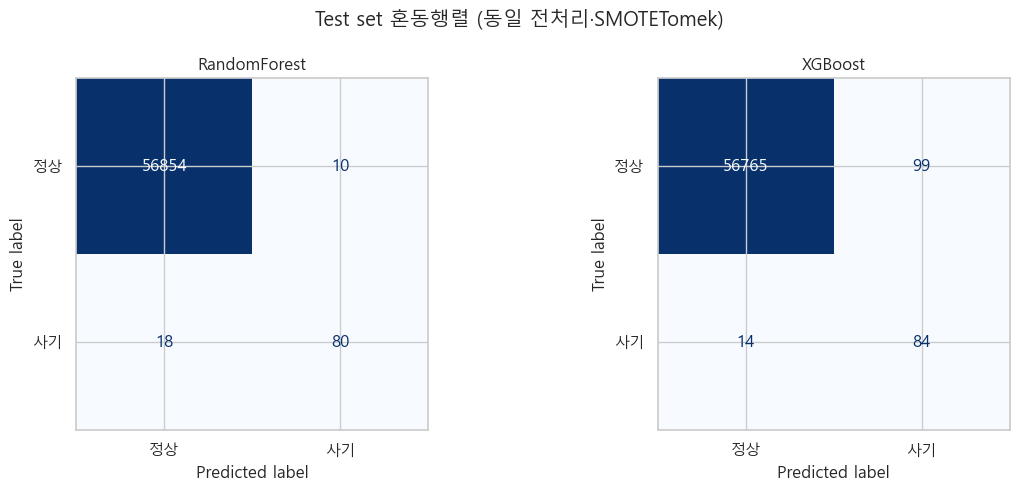

In [15]:
# 보고서 그림 14·15 — XGB 학습 후 SHAP Waterfall, RandomForest vs XGB 혼동행렬
# (동일 Train_res, 동일 Test; 모델 구조·튜닝 서술용 도식 11~13은 보고서에서 별도 제작)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    base_score=0.5,
)
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test)

# --- 그림 14: SHAP (plot_waterfall_row — 대시보드와 동일 파이프라인) ---
from shap_waterfall_style import plot_waterfall_row

_bg = X_train_res.iloc[: min(500, len(X_train_res))]


def _xgb_fraud_proba(X):
    return xgb_model.predict_proba(X)[:, 1]


explainer = shap.Explainer(_xgb_fraud_proba, _bg)
row = X_test.iloc[[0]]
fraud_prob_row = float(xgb_model.predict_proba(row)[:, 1][0])

_prev_family = plt.rcParams["font.family"]
_prev_sans = plt.rcParams["font.sans-serif"]
try:
    fig = plot_waterfall_row(explainer, row, fraud_prob_row, max_display=15)
    fig.savefig(OUT / "14_shap_waterfall.png", dpi=150, bbox_inches="tight")
    plt.show()
finally:
    plt.rcParams["font.family"] = _prev_family
    plt.rcParams["font.sans-serif"] = _prev_sans
plt.clf()

# --- 그림 15: 혼동행렬 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf), display_labels=["정상", "사기"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("RandomForest")
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb), display_labels=["정상", "사기"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("XGBoost")
plt.suptitle("Test set 혼동행렬 (동일 전처리·SMOTETomek)")
plt.tight_layout()
plt.savefig(OUT / "15_confusion_matrix_rf_vs_xgb.png", dpi=150)
plt.show()


## 모델 비교 실험 (5종) — `scripts/model_comparison_visualize.py`

**비교 대상:** 로지스틱 회귀 baseline·튜닝(CV=F2), 랜덤 포레스트 baseline, XGBoost baseline·튜닝(CV=F2).  
**데이터:** 이 노트북과 동일하게 `fds_pipeline` 전처리 → 층화 분할 → Train만 SMOTETomek.

아래 셀을 실행하면 `report_figures/`에 `model_compare_all_*.png`와 `model_compare_all_metrics.csv`가 생성된다. **SMOTETomek + RandomizedSearchCV** 때문에 전체 CSV 기준 **수십 분** 걸릴 수 있다.

정본 로직은 스크립트에 두고, 여기서는 **실행·결과 확인·보고서용 캡처**용으로 쓴다. 전처리 튜토리얼은 `fds_preprocessing_walkthrough.ipynb`, 누출·스케일 비교는 `docs/leakage_and_scaling.md`·`compare_preprocessing_strategies.py`를 병행하면 된다.

In [16]:
# 모델 비교 스크립트 실행 (프로젝트 루트에서 이 노트북을 띄웠다고 가정)
import subprocess
import sys
from pathlib import Path

_ROOT = Path.cwd()
_script = _ROOT / "scripts" / "model_comparison_visualize.py"
if not _script.is_file():
    raise FileNotFoundError(f"스크립트 없음: {_script}")

proc = subprocess.run(
    [sys.executable, str(_script)],
    cwd=str(_ROOT),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr, file=sys.stderr)
print("종료 코드:", proc.returncode)
if proc.returncode != 0:
    raise RuntimeError("model_comparison_visualize.py 실패")

[1/5] 로지스틱 baseline...
[2/5] 로지스틱 RandomizedSearchCV (F2)...
[3/5] 랜덤 포레스트 baseline...
[4/5] XGBoost baseline...
[5/5] XGBoost RandomizedSearchCV (F2)...
저장: D:\personalProject\report_figures\model_compare_all_metrics.csv
저장: D:\personalProject\report_figures\model_compare_all_metrics_bar.png
저장: D:\personalProject\report_figures\model_compare_all_roc.png
저장: D:\personalProject\report_figures\model_compare_all_pr.png
저장: D:\personalProject\report_figures\model_compare_all_confusion.png
저장: D:\personalProject\report_figures\model_compare_all_calibration.png
저장: D:\personalProject\report_figures\model_compare_all_threshold_curves.png

표 요약:
                  model  cv_best_f2_train   recall       f1       f2   pr_auc  roc_auc
    로지스틱 회귀 (baseline)               NaN 0.918367 0.108173 0.229826 0.719884 0.973026
로지스틱 회귀 (tuned, CV=F2)          0.936532 0.918367 0.108043 0.229592 0.721109 0.972904
    랜덤 포레스트 (baseline)               NaN 0.816327 0.851064 0.829876 0.872667 0.972507
    XGBo

In [ ]:
# 생성된 CSV·PNG 확인 (OUT = report_figures)
from IPython.display import HTML, Image, display

import pandas as pd

_csv = OUT / "model_compare_all_metrics.csv"
if _csv.is_file():
    display(HTML("<b>model_compare_all_metrics.csv</b>"))
    display(pd.read_csv(_csv))
else:
    print("CSV 없음. 위 셀을 먼저 성공적으로 실행하세요.")

_figs = [
    "model_compare_all_metrics_bar.png",
    "model_compare_all_roc.png",
    "model_compare_all_pr.png",
    "model_compare_all_confusion.png",
    "model_compare_all_calibration.png",
    "model_compare_all_threshold_curves.png",
]
for _name in _figs:
    _p = OUT / _name
    if _p.is_file():
        display(HTML(f"<h4>{_name}</h4>"))
        display(Image(filename=str(_p)))
    else:
        print("없음:", _p.name)

In [24]:
# 생성된 파일 목록
sorted(OUT.glob("*.png"))


[WindowsPath('report_figures/01_class_pie.png'),
 WindowsPath('report_figures/02_corr_heatmap.png'),
 WindowsPath('report_figures/03_amount_boxplot.png'),
 WindowsPath('report_figures/04_amount_hist_before_after.png'),
 WindowsPath('report_figures/05_time_kde_by_day_seconds.png'),
 WindowsPath('report_figures/06_smote_class_bar_before_after.png'),
 WindowsPath('report_figures/07_correlation_heatmap_comparison.png'),
 WindowsPath('report_figures/08_confusion_matrix_rf_vs_xgb.png'),
 WindowsPath('report_figures/09_shap_waterfall.png')]

## 2차 모델 비교 (3종, 검증 임계값) — `scripts/model_comparison_round2.py`

**대상:** 랜덤 포레스트 baseline, XGBoost baseline, XGBoost tuned(CV=F2). 로지스틱은 제외.

**절차:** 원시 train을 fit|검증으로 층화 분할 → SMOTETomek은 fit에만 → **검증 확률에서 F2가 최대인 임계값**을 모델마다 선택 → **동일 test**에서만 Recall·F1·F2 등을 계산.

**산출:** `report_figures/model_round2_val_thr.csv` 하나(그림 없음). 1차(`model_compare_all_*`)와 학습에 쓰는 train 양이 달라 **숫자를 직접 1:1 대응하지 말 것**.

아래 셀은 **수십 분** 걸릴 수 있다(XGB RandomizedSearchCV).

In [ ]:
# 2차: 검증 임계값 + test 지표 (CSV만)
import subprocess
import sys
from pathlib import Path

_ROOT = Path.cwd()
_script = _ROOT / "scripts" / "model_comparison_round2.py"
if not _script.is_file():
    raise FileNotFoundError(f"스크립트 없음: {_script}")

proc = subprocess.run(
    [sys.executable, str(_script)],
    cwd=str(_ROOT),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr, file=sys.stderr)
print("종료 코드:", proc.returncode)
if proc.returncode != 0:
    raise RuntimeError("model_comparison_round2.py 실패")

In [ ]:
# model_round2_val_thr.csv 확인 (캡처·보고서용)
from IPython.display import HTML, display

import pandas as pd

_r2 = OUT / "model_round2_val_thr.csv"
if _r2.is_file():
    display(HTML("<b>model_round2_val_thr.csv</b>"))
    display(pd.read_csv(_r2))
else:
    print("CSV 없음. 위 셀을 먼저 성공적으로 실행하세요.")